In [181]:
!pip install pennylane

In [182]:
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as np
import torch
import math

In [183]:
n_qubits = 5         # number of qubits
n_layers = 4         # number of repetition layers
n_steps = 50          # optimization steps
learning_rate = 0.4   # for gradient descent

In [184]:
dev = qml.device('default.qubit', wires=n_qubits)


In [185]:
# Build the Hamiltonian: H = - sum Z_i Z_{i+1} - sum X_i
def build_hamiltonian(n):
    """Return the Hamiltonian
    H = - sum Z_i Z_{i+1} - sum X_i
     """
    coeffs = []
    ops = []
    # - sum Z_i Z_{i+1}
    for i in range(n - 1):
        coeffs.append(-1.0)
        ops.append(qml.PauliZ(i) @ qml.PauliZ(i + 1))
    # - sum X_i
    for i in range(n):
        coeffs.append(-1.0)
        ops.append(qml.PauliX(i))
    return qml.Hamiltonian(coeffs, ops)

H = build_hamiltonian(n_qubits)

In [186]:
def circuit(params):
    """Circuit with n_layers of (RX, RY) + CNOT entanglement."""
    params = params.reshape((n_layers, n_qubits, 2))
    for layer in range(n_layers):
        # Rotation layer
        for qubit in range(n_qubits):
            qml.RX(params[layer, qubit, 0], wires=qubit)
            qml.RY(params[layer, qubit, 1], wires=qubit)
        # Entanglement layer (linear CNOT chain)
        for qubit in range(n_qubits - 1):
            qml.CNOT(wires=[qubit, qubit + 1])
        qml.Barrier()


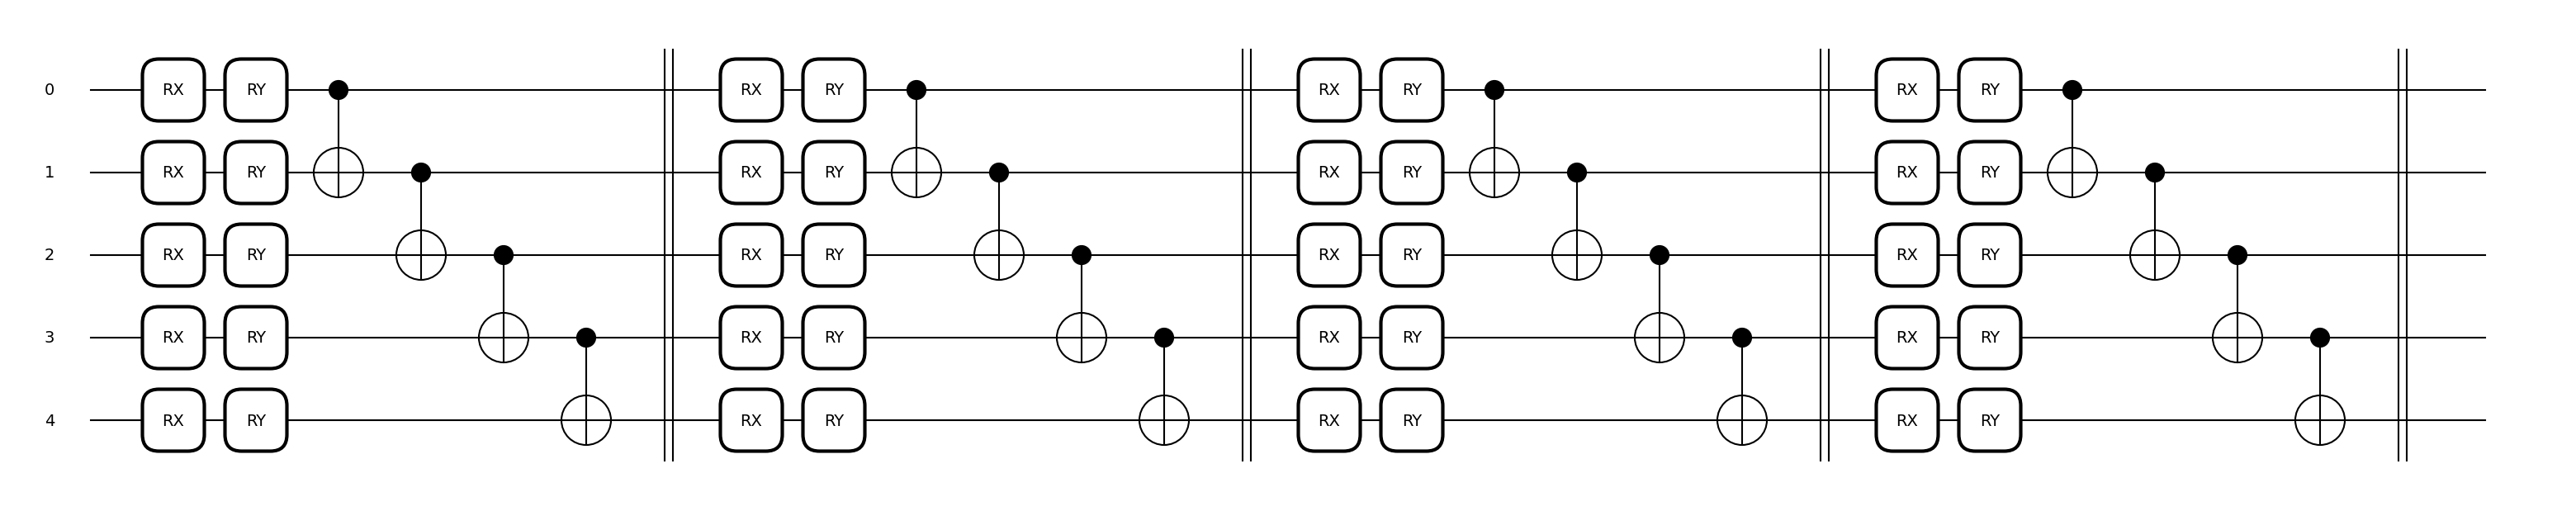

In [187]:
fig, ax = qml.draw_mpl(circuit)(np.random.randn(n_layers * n_qubits * 2))
plt.show()

In [188]:
@qml.qnode(dev)
def cost_fn(params):
    circuit(params)
    return qml.expval(H)


Step   0  Energy = -0.237169
Step  10  Energy = -5.297844
Step  20  Energy = -4.348591
Step  30  Energy = -5.030813
Step  40  Energy = -4.501628

Final energy = -4.424192


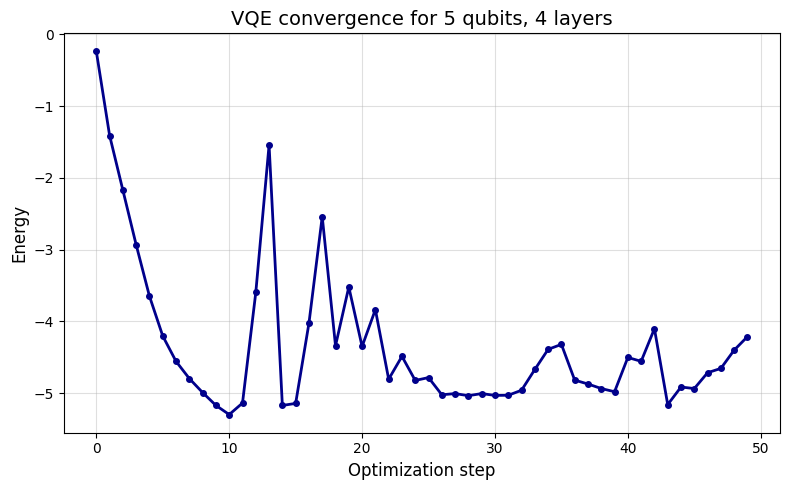

In [189]:
np.random.seed(42)
init_params = np.random.randn(n_layers * n_qubits * 2, requires_grad=True)

grad_fn = qml.grad(cost_fn)

# Optimisation loop
energies = []
params = init_params
for step in range(n_steps):
    energy = cost_fn(params)
    gradients = grad_fn(params)
    # print(gradients.shape)
    energies.append(energy)
    params = params - learning_rate * gradients
    if step % 10 == 0:
        print(f"Step {step:3d}  Energy = {energy:.6f}")

final_energy = cost_fn(params)
print(f"\nFinal energy = {final_energy:.6f}")

# Plot convergence with matplotlib
plt.figure(figsize=(8, 5))
plt.plot(energies, 'o-', color='darkblue', lw=2, markersize=4)
plt.xlabel("Optimization step", fontsize=12)
plt.ylabel("Energy", fontsize=12)
plt.title(f"VQE convergence for {n_qubits} qubits, {n_layers} layers", fontsize=14)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## D adapted SGD Implementation
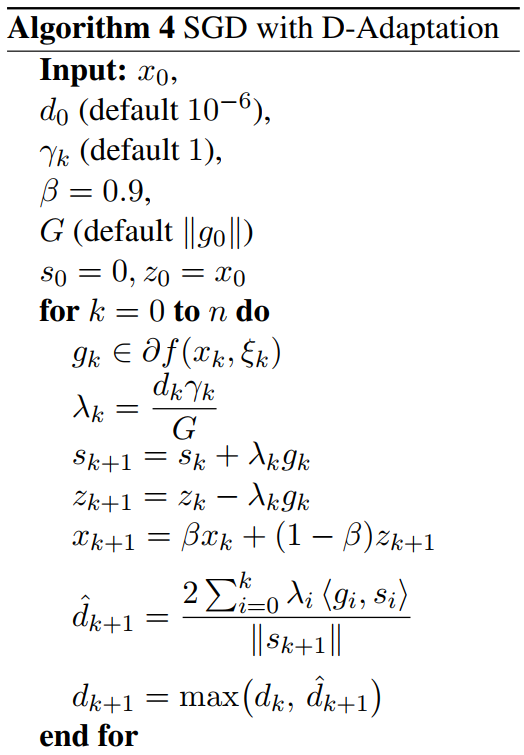

In [190]:
class DAdaptSGD:
    """
    NumPy implementation of D-Adapt SGD.
    x_init: initial params vector
    lr: gamma
    z: momentum accumulator
    """
    def __init__(self, x_init, lr=1.0, momentum=0.9, d0=1e-6):
        # Model parameters
        self.x = np.array(x_init, dtype=np.float64)

        # State variables
        self.x0 = self.x.copy()          # Initial weights
        self.s = np.zeros_like(self.x)   # Sum of weighted gradients
        self.z = self.x.copy()           # sort of momentum accumulator

        # Hyperparameters
        self.beta = momentum
        self.lr = lr

        # D-Adaptation specific trackers
        self.d = d0
        self.k = 0
        self.numerator_weighted = 0.0
        self.g0_norm = None

    def step(self, grad):
        g = np.array(grad, dtype=np.float64)

        if self.k==0:
            self.g0_norm = np.linalg.norm(g)
            if self.g0_norm == 0:
                self.g0_norm = 1e-8


        lambda_k = self.d * self.lr / self.g0_norm
        delta_numerator_weighted = lambda_k * np.sum(g * self.s)

        self.s += lambda_k * g
        self.z = self.x0 - self.s
        self.x = self.beta * self.x + (1-self.beta) * self.z

        self.numerator_weighted += delta_numerator_weighted

        d_k_1_estimate = 2 * self.numerator_weighted / (np.linalg.norm(self.s) +1e-8)
        self.d = max(self.d, d_k_1_estimate)

        self.k += 1
        return self.x

In [191]:
energies_d_adapted_sgd = []

test_momenta = [0, 0.3, 0.6, 0.9]
for momentum in test_momenta:
    np.random.seed(42)
    init_params = np.random.randn(n_layers * n_qubits * 2, requires_grad=True)

    params = init_params
    opt = DAdaptSGD(params, momentum=momentum)
    grad_fn = qml.grad(cost_fn)

    # Optimisation loop
    energies_d = []

    for step in range(n_steps):
        energy = cost_fn(params)
        gradients = grad_fn(params)
        # print(gradients.shape)
        energies_d.append(energy)
        params = opt.step(gradients)
        if step % 10 == 0:
            print(f"Step {step:3d}  Energy = {energy:.6f}")

    final_energy = cost_fn(params)
    print(f"\nFinal energy = {final_energy:.6f}")
    energies_d_adapted_sgd.append(energies_d)

Step   0  Energy = -0.237169
Step  10  Energy = -0.237432
Step  20  Energy = -0.300875
Step  30  Energy = -4.732113
Step  40  Energy = -1.287515

Final energy = -0.942063
Step   0  Energy = -0.237169
Step  10  Energy = -0.237392
Step  20  Energy = -0.291160
Step  30  Energy = -4.544974
Step  40  Energy = -2.955424

Final energy = -3.856613
Step   0  Energy = -0.237169
Step  10  Energy = -0.237330
Step  20  Energy = -0.276251
Step  30  Energy = -4.015630
Step  40  Energy = -4.555731

Final energy = -4.270239
Step   0  Energy = -0.237169
Step  10  Energy = -0.237224
Step  20  Energy = -0.250489
Step  30  Energy = -2.162293
Step  40  Energy = -5.335641

Final energy = -5.764230


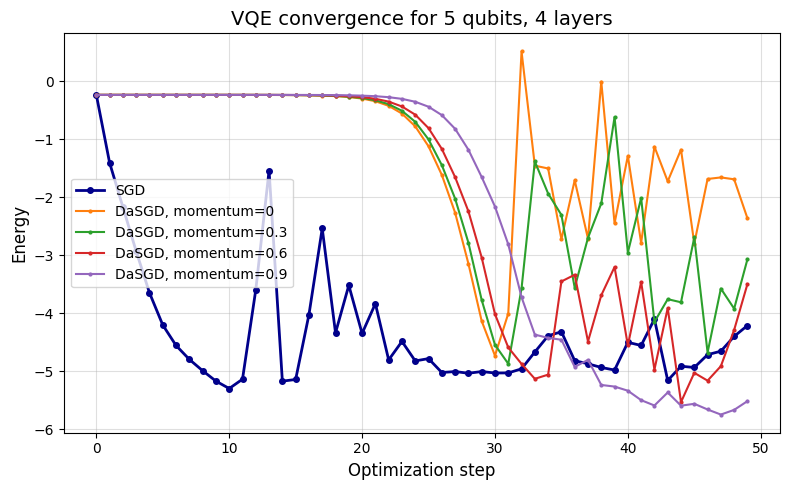

In [192]:


plt.figure(figsize=(8, 5))
plt.plot(energies, 'o-', color='darkblue', lw=2, markersize=4, label="SGD")
for i, energies_d in enumerate(energies_d_adapted_sgd):
    plt.plot(energies_d, 'o-', color=f"C{i+1}", lw=1.5, markersize=2, label=f"DaSGD, momentum={test_momenta[i]}")
plt.legend()
plt.xlabel("Optimization step", fontsize=12)
plt.ylabel("Energy", fontsize=12)
plt.title(f"VQE convergence for {n_qubits} qubits, {n_layers} layers", fontsize=14)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()